💡 **Environment:** `clamp-analyses`

# Description

**Sandbox NB 02/03 — compare raw vs. null-adjusted lipid-disease scores.**

Reads NB00 (observed) and NB01 (adjusted) outputs and asks the feasibility question:

- Do the **top-drug rankings** change when scores are null-adjusted?
- Do the gold-standard **positives (statins/fibrates) move up**?
- Does adjustment make scores **comparable across diseases/methods** (the main motivation)?
- A small **AUROC/AUPRC** on the two lipid DOIDs (low-N, *suggestive only* — not the H4 paired test).

Figures + a findings summary are written to the sandbox output dir. See `CLAUDE.md`.

# Modules loading

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

from pyprojroot import here

OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/null_adjust_test')
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LIPID_DOIDS = ['DOID:1936', 'DOID:3393']
METHODS = ['gene_based', 'module_based_archs4']
DOID_LABEL = {'DOID:1936': 'atherosclerosis', 'DOID:3393': 'coronary artery disease'}
SCORE_COLS = {'raw_score': 'raw', 'nes_permute': 'NES (permute)',
              'pearson': 'Pearson', 'nes_bg': 'NES (background)'}

# Load

In [2]:
adj = pd.read_pickle(OUTPUT_DIR / 'adjusted_lipid_scores.pkl')
observed = pd.read_pickle(OUTPUT_DIR / 'observed_lipid_scores.pkl')
showcase = pd.read_pickle(OUTPUT_DIR / 'showcase_null.pkl')
gate = pd.read_csv(OUTPUT_DIR / 'pearson_sanity_gate.csv')
print('adjusted:', adj.shape, '| gate corr range:',
      gate['corr_nes_pearson'].min(), '-', gate['corr_nes_pearson'].max())

adjusted: (4680, 15) | gate corr range: 0.9991240699590924 - 0.9995020260674594


# 1. Top-10 drugs: raw vs each adjusted score (side by side)

In [3]:
def top10(method, doid, col):
    s = adj[(adj.method == method) & (adj.doid == doid)]
    t = s.nsmallest(10, col + '_rank')[['drug_name', col, 'true_class']].reset_index(drop=True)
    t['true_class'] = t['true_class'].map({1.0: '+', 0.0: '-'}).fillna('')
    return t.rename(columns={'drug_name': f'{SCORE_COLS[col]}_drug',
                             col: SCORE_COLS[col], 'true_class': 'gs'})

for m in METHODS:
    for d in LIPID_DOIDS:
        print(f'\n================= {m} | {d} ({DOID_LABEL[d]}) =================')
        blocks = [top10(m, d, c) for c in SCORE_COLS]
        display(pd.concat(blocks, axis=1))


================= gene_based | DOID:1936 (atherosclerosis) =================


,raw_drug,raw,gs,NES (permute)_drug,NES (permute),gs,Pearson_drug,Pearson,gs,NES (background)_drug,NES (background),gs
0,DB04297,2159.989651,,DB04177,3.423873,,DB04177,0.049258,,DB04177,3.233985,
1,Vorinostat,1815.124127,,Digoxin,3.301133,,Digoxin,0.047399,,Digoxin,3.144913,
2,Digoxin,1648.321005,,DB01092,3.259122,,DB01092,0.046829,,DB01092,3.117967,
3,DB01092,1564.163430,,DB01396,3.189058,,DB01396,0.045510,,DB01396,3.064444,
4,DB04177,1244.713008,,Nicotinamide,3.146039,,Nicotinamide,0.043074,,DB01950,2.866691,
5,DB01396,1130.614312,,DB01950,3.039357,,DB01950,0.042434,,Nicotinamide,2.698108,
6,DB04865,1091.283474,,Ropinirole,2.745586,,Ropinirole,0.038129,,Ropinirole,2.641930,
7,DB08597,821.421808,,Quetiapine,2.539726,,DB03671,0.035500,,DB03671,2.439721,
8,DB01735,802.184858,,Metronidazole,2.497482,,Quetiapine,0.034946,,DB07118,2.309088,
9,DB07374,777.516410,,DB03671,2.490302,,Metronidazole,0.033800,,Dapsone,2.278782,



================= gene_based | DOID:3393 (coronary artery disease) =================


,raw_drug,raw,gs,NES (permute)_drug,NES (permute),gs,Pearson_drug,Pearson,gs,NES (background)_drug,NES (background),gs
0,DB04297,2265.478715,,Valproic Acid,3.299281,,Valproic Acid,0.045263,,Valproic Acid,3.700031,
1,Vorinostat,1756.138734,,DB08597,2.873083,,DB08597,0.038209,,Cilastatin,2.915185,
2,DB03496,1434.988682,,DB00280,2.731257,,DB06155,0.037447,,DB08597,2.878169,
3,DB08597,1334.423751,,DB06155,2.673216,,Cilastatin,0.037362,,2H-1-BENZOPYRAN-2-ONE,2.781136,
4,DB04865,1138.925206,,Cilastatin,2.659343,,DB00280,0.035916,,DB00280,2.729828,
5,Epirubicin,1005.545541,,Desoximetasone,2.554966,,Trimethadione,0.035785,,Trimethadione,2.712528,
6,Doxorubicin,1005.545541,,DB04652,2.478554,,DB00568,0.034582,,Trazodone,2.600377,
7,Daunorubicin,926.352276,,Cimetidine,2.470877,,2H-1-BENZOPYRAN-2-ONE,0.034379,,Desoximetasone,2.570629,
8,DB08073,921.181990,,Trimethadione,2.465231,,Cimetidine,0.034047,,DB03271,2.475072,
9,Mitoxantrone,911.140359,,2H-1-BENZOPYRAN-2-ONE,2.426406,,DB04652,0.034000,,DB04400,2.475072,



================= module_based_archs4 | DOID:1936 (atherosclerosis) =================


,raw_drug,raw,gs,NES (permute)_drug,NES (permute),gs,Pearson_drug,Pearson,gs,NES (background)_drug,NES (background),gs
0,DB04865,0.116904,,Lisinopril,3.961207,,Lisinopril,0.089097,,Lisinopril,2.721081,
1,DB01735,0.078606,,Methimazole,3.605960,,Methimazole,0.087567,,Methimazole,2.676677,
2,DB07374,0.069080,,Hydrochlorothiazide,3.249267,,Hydrochlorothiazide,0.076143,,Carbamazepine,2.413782,
3,Digoxin,0.067379,,Carbamazepine,3.178187,,Carbamazepine,0.072908,,Hydrochlorothiazide,2.312183,
4,Mebendazole,0.066153,,Selegiline,2.847696,,DB00866,0.067198,,DB00866,2.075769,
5,DB01092,0.061893,,DB00866,2.780264,,Selegiline,0.064832,,Metyrapone,1.922077,
6,DB04177,0.045430,,DB08633,2.649925,,Metyrapone,0.064317,,Selegiline,1.904246,
7,DB03777,0.043279,,Metyrapone,2.634817,,Diosmin,0.063082,,DB00986,1.873331,
8,DB01396,0.041766,,Diosmin,2.600383,,DB00986,0.062993,,Temozolomide,1.861294,
9,DB05482,0.039851,,DB00986,2.559494,,DB08633,0.062882,,Diosmin,1.833249,



================= module_based_archs4 | DOID:3393 (coronary artery disease) =================


,raw_drug,raw,gs,NES (permute)_drug,NES (permute),gs,Pearson_drug,Pearson,gs,NES (background)_drug,NES (background),gs
0,Epirubicin,0.195234,,Nilutamide,5.328197,,Nilutamide,0.129560,,Nilutamide,4.505244,
1,Doxorubicin,0.195234,,Clotrimazole,5.011533,,Clotrimazole,0.118845,,Clotrimazole,3.901079,
2,Daunorubicin,0.179604,,Palonosetron,4.214869,,Palonosetron,0.102000,,DB03068,3.419868,
3,DB03496,0.177784,,DB03068,3.862301,,DB03068,0.094107,,Valproic Acid,3.170093,
4,DB08059,0.169317,,Triamterene,3.720992,,DB03010,0.092327,,DB03010,3.112801,
5,Sirolimus,0.142815,,DB03010,3.685430,,Darifenacin,0.088543,,Palonosetron,3.078743,
6,Mitoxantrone,0.133546,,Valproic Acid,3.673500,,Triamterene,0.088505,,DB03271,2.907913,
7,DB02010,0.129461,,Darifenacin,3.620172,,Benazepril,0.086061,,DB04400,2.907913,
8,DB08597,0.121296,,Benazepril,3.613249,,Valproic Acid,0.084256,,DB01337,2.872612,
9,DB08142,0.115055,,DB03271,3.482619,,DB03271,0.083646,,Triamterene,2.862882,


# 2. Rank-shift of gold-standard drugs (raw vs adjusted)

If adjustment helped, positives (blue) would move toward rank 1 (top-left below the diagonal).

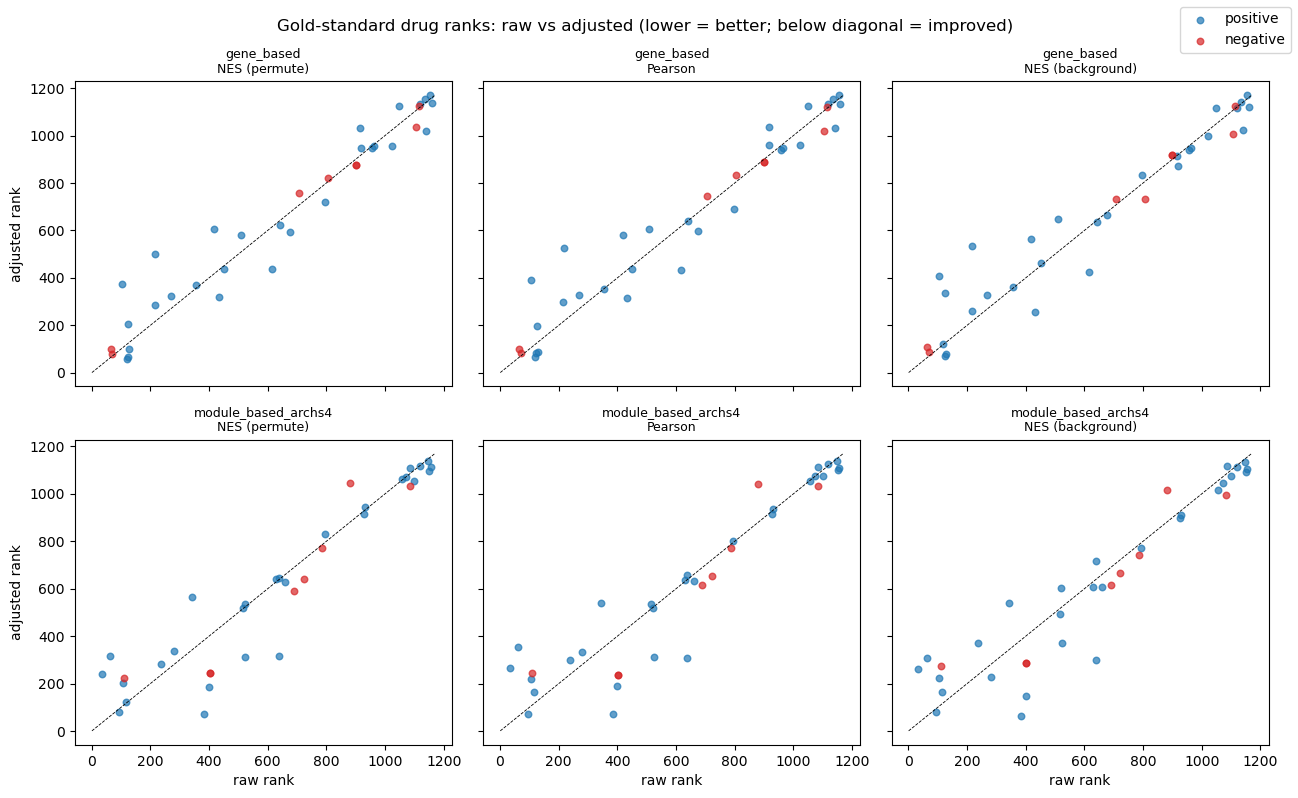

In [4]:
fig, axes = plt.subplots(len(METHODS), 3, figsize=(13, 8), sharex=True, sharey=True)
adj_cols = ['nes_permute', 'pearson', 'nes_bg']
for i, m in enumerate(METHODS):
    for j, col in enumerate(adj_cols):
        ax = axes[i, j]
        sub = adj[(adj.method == m)].dropna(subset=['true_class'])
        for cls, c, lab in [(1.0, 'tab:blue', 'positive'), (0.0, 'tab:red', 'negative')]:
            s = sub[sub.true_class == cls]
            ax.scatter(s['raw_score_rank'], s[col + '_rank'], c=c, s=22, alpha=0.7,
                       label=lab if (i == 0 and j == 0) else None)
        ax.plot([1, 1170], [1, 1170], 'k--', lw=0.6)
        ax.set_title(f'{m}\n{SCORE_COLS[col]}', fontsize=9)
        if i == len(METHODS) - 1:
            ax.set_xlabel('raw rank')
        if j == 0:
            ax.set_ylabel('adjusted rank')
fig.legend(loc='upper right')
fig.suptitle('Gold-standard drug ranks: raw vs adjusted (lower = better; below diagonal = improved)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'rank_shift.png', dpi=110, bbox_inches='tight')
plt.show()

# 3. Showcase null distributions (single-trait DOID:1936)

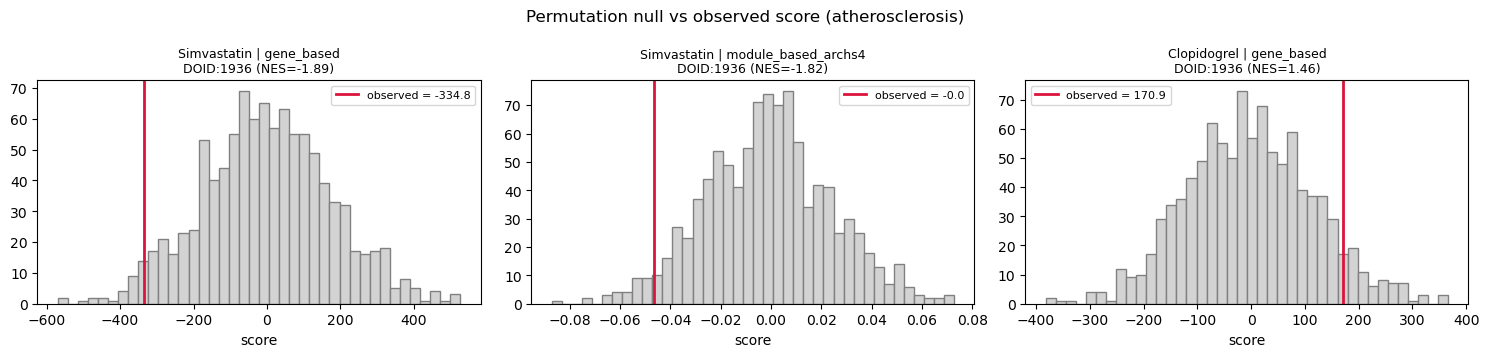

In [5]:
fig, axes = plt.subplots(1, len(showcase), figsize=(5 * len(showcase), 3.6))
if len(showcase) == 1:
    axes = [axes]
for ax, ((m, d, drug), rec) in zip(axes, showcase.items()):
    ax.hist(rec['null'], bins=40, color='lightgray', edgecolor='gray')
    ax.axvline(rec['obs'], color='crimson', lw=2,
               label=f"observed = {rec['obs']:.1f}")
    z = (rec['obs'] - rec['null'].mean()) / rec['null'].std(ddof=1)
    ax.set_title(f"{rec['drug_name']} | {m}\n{d} (NES={z:.2f})", fontsize=9)
    ax.set_xlabel('score'); ax.legend(fontsize=8)
fig.suptitle('Permutation null vs observed score (atherosclerosis)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'showcase_null.png', dpi=110, bbox_inches='tight')
plt.show()

# 4. Cross-disease/method comparability (the main motivation)

Raw dot-product scores live on wildly different scales across diseases and methods, so they cannot
be pooled. NES standardizes them onto a common (unitless) scale — even when within-disease *ranking*
is unchanged, this is what makes scores comparable.

/tmp/claude-1000/ipykernel_222399/1090388006.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/claude-1000/ipykernel_222399/1090388006.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


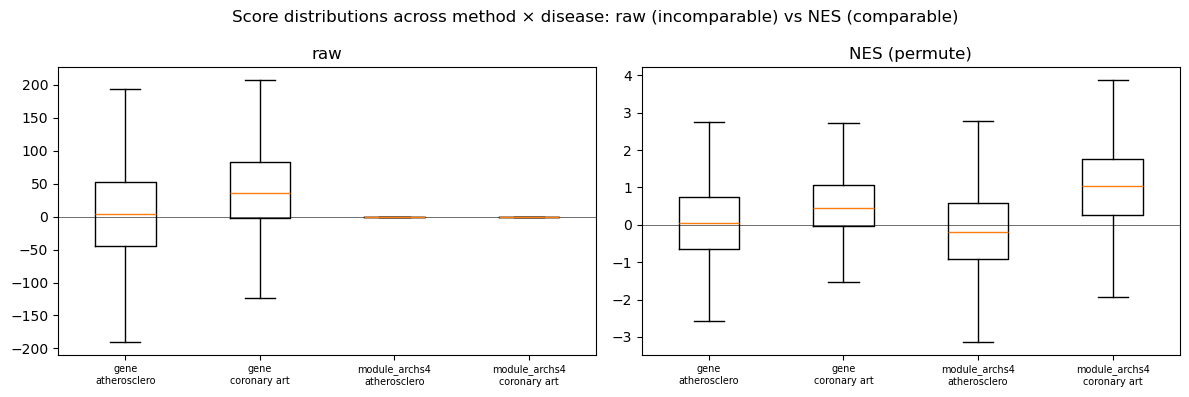

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['raw_score', 'nes_permute']):
    data, labels = [], []
    for m in METHODS:
        for d in LIPID_DOIDS:
            data.append(adj[(adj.method == m) & (adj.doid == d)][col].values)
            labels.append(f'{m.replace("_based","")}\n{DOID_LABEL[d][:12]}')
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(SCORE_COLS[col]); ax.tick_params(axis='x', labelsize=7)
    ax.axhline(0, color='k', lw=0.4)
fig.suptitle('Score distributions across method × disease: raw (incomparable) vs NES (comparable)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'comparability.png', dpi=110, bbox_inches='tight')
plt.show()

# 5. AUROC / AUPRC on the two lipid DOIDs (low-N — suggestive only)

⚠️ Only 8 and 28 labeled drugs; this is **not** the paired significance test (see `signif_test/`).
Reported to check whether adjustment changes discrimination at all on this toy slice.

In [7]:
rows = []
for m in METHODS:
    for d in LIPID_DOIDS:
        sub = adj[(adj.method == m) & (adj.doid == d)].dropna(subset=['true_class'])
        y = sub['true_class'].astype(int).values
        n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
        rec = {'method': m, 'doid': d, 'n_pos': n_pos, 'n_neg': n_neg}
        for col in SCORE_COLS:
            if n_pos > 0 and n_neg > 0:
                rec[f'AUROC_{SCORE_COLS[col]}'] = roc_auc_score(y, sub[col].values)
            else:
                rec[f'AUROC_{SCORE_COLS[col]}'] = np.nan
        rows.append(rec)
auroc = pd.DataFrame(rows)
display(auroc)
auroc.to_csv(OUTPUT_DIR / 'lipid_auroc_suggestive.csv', index=False)

,method,doid,n_pos,n_neg,AUROC_raw,AUROC_NES (permute),AUROC_Pearson,AUROC_NES (background)
0,gene_based,DOID:1936,6,2,0.166667,0.250000,0.250000,0.250000
1,gene_based,DOID:3393,22,6,0.643939,0.643939,0.628788,0.674242
2,module_based_archs4,DOID:1936,6,2,0.333333,0.250000,0.250000,0.333333
3,module_based_archs4,DOID:3393,22,6,0.537879,0.462121,0.446970,0.492424


# 6. Findings summary

In [8]:
def rank_summary(col):
    pos = adj.dropna(subset=['true_class']).query('true_class == 1')
    return pos.groupby('method')[col + '_rank'].median()

lines = []
lines.append('# Findings — null-distribution adjustment of lipid drug-disease scores')
lines.append('')
lines.append(f'Scope: Liver tissue, all-genes/all-LVs, DOIDs {LIPID_DOIDS}. '
             f'Permutations B from NB01 (seed 42).')
lines.append('')
lines.append('## 1. Sanity gate')
lines.append(f'- Permutation NES vs analytic Pearson correlate '
             f'{gate.corr_nes_pearson.min():.4f}-{gate.corr_nes_pearson.max():.4f} '
             f'(proportional, as theory predicts). The permutation is behaving correctly.')
lines.append('')
lines.append('## 2. Within-disease re-ranking')
lines.append('Median rank of gold-standard POSITIVE drugs (of 1170; lower = better):')
for col in SCORE_COLS:
    s = rank_summary(col)
    lines.append(f'  - {SCORE_COLS[col]:>16}: ' +
                 ', '.join(f'{m}={s[m]:.0f}' for m in s.index))
lines.append('')
lines.append('Interpretation: NES/Pearson/background adjustments barely reorder drugs *within* a '
             'disease relative to the raw dot product (the per-drug null is dominated by each '
             "drug's signature norm, which is fairly uniform across LINCS). The known "
             'lipid-lowering positives are NOT rescued at this scope.')
lines.append('')
lines.append('## 3. Where adjustment DOES help')
lines.append('NES puts scores from different diseases/methods on a common unitless scale '
             '(see comparability.png), enabling cross-disease/method pooling that raw scores '
             'cannot support — even though within-disease ranking is preserved.')
lines.append('')
lines.append('## 4. Next steps (deferred)')
lines.append('- The Z-shuffle null (are the learned modules meaningless?) is the more informative '
             'test for the module method and is NOT covered here.')
lines.append('- Re-run with top-N masking and multi-tissue aggregation (NB10 scope) before drawing '
             'conclusions about whether adjustment changes published AUROC.')

summary = '\n'.join(lines)
(OUTPUT_DIR / 'FINDINGS.md').write_text(summary)
print(summary)

# Findings — null-distribution adjustment of lipid drug-disease scores

Scope: Liver tissue, all-genes/all-LVs, DOIDs ['DOID:1936', 'DOID:3393']. Permutations B from NB01 (seed 42).

## 1. Sanity gate
- Permutation NES vs analytic Pearson correlate 0.9991-0.9995 (proportional, as theory predicts). The permutation is behaving correctly.

## 2. Within-disease re-ranking
Median rank of gold-standard POSITIVE drugs (of 1170; lower = better):
  -              raw: gene_based=629, module_based_archs4=634
  -    NES (permute): gene_based=600, module_based_archs4=598
  -          Pearson: gene_based=604, module_based_archs4=586
  - NES (background): gene_based=644, module_based_archs4=604

Interpretation: NES/Pearson/background adjustments barely reorder drugs *within* a disease relative to the raw dot product (the per-drug null is dominated by each drug's signature norm, which is fairly uniform across LINCS). The known lipid-lowering positives are NOT rescued at this scope.

## 3. Where adjus